# Large Language Models y Arquitecturas Transformer


**Temas cubiertos:**
1. Arquitecturas Transformer: Encoder-Only, Decoder-Only, Encoder-Decoder  
2. BERT — representaciones bidireccionales y pretraining  
3. GPT — autoregresivo causal y escalado  
4. LLaMA, DeepSeek, Qwen — eficiencia y razonamiento  
5. Pretraining, Fine-tuning e Instruction Tuning  
6. Evaluación y métricas

> **Entorno recomendado:** Python ≥ 3.8 · PyTorch · Transformers · Datasets


## Setup e imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
import warnings, math, random, textwrap
from collections import Counter

warnings.filterwarnings('ignore')
torch.manual_seed(42); np.random.seed(42); random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.labelsize': 11,
})
print("Setup completado")


Dispositivo: cuda
Setup completado


---
## 1. Panorama: Tres Familias de Transformers

El paper *"Attention Is All You Need"* (Vaswani et al., 2017) propuso una arquitectura
**Encoder–Decoder**. Desde entonces, la comunidad ha derivado tres variantes principales:

| Arquitectura | Flujo de información | Tarea natural | Modelos icónicos |
|---|---|---|---|
| **Encoder-Only** | Bidireccional | Comprensión / Clasificación | BERT, RoBERTa, DeBERTa |
| **Decoder-Only** | Causal (izq → der) | Generación de texto | GPT, LLaMA, DeepSeek, Qwen |
| **Encoder-Decoder** | Enc. bidirecional → Dec. causal | Seq2Seq | T5, BART, mT5 |

### 1.1 Diferencia clave: la máscara de atención

La diferencia fundamental entre las tres familias está en **qué tokens puede ver cada posición**:

$$A_{ij} = \text{softmax}\!\left(\frac{q_i \cdot k_j^\top}{\sqrt{d_k}} + m_{ij}\right)$$

donde $m_{ij} \in \{0, -\infty\}$ es la **máscara**:

- **Encoder:** $m_{ij} = 0 \; \forall i,j$ — cada token ve a todos (bidireccional)  
- **Decoder:** $m_{ij} = -\infty$ si $j > i$ — máscara causal  
- **Cross-attention:** $Q$ viene del decoder, $K,V$ del encoder


### 1.2 Visualización de las tres arquitecturas

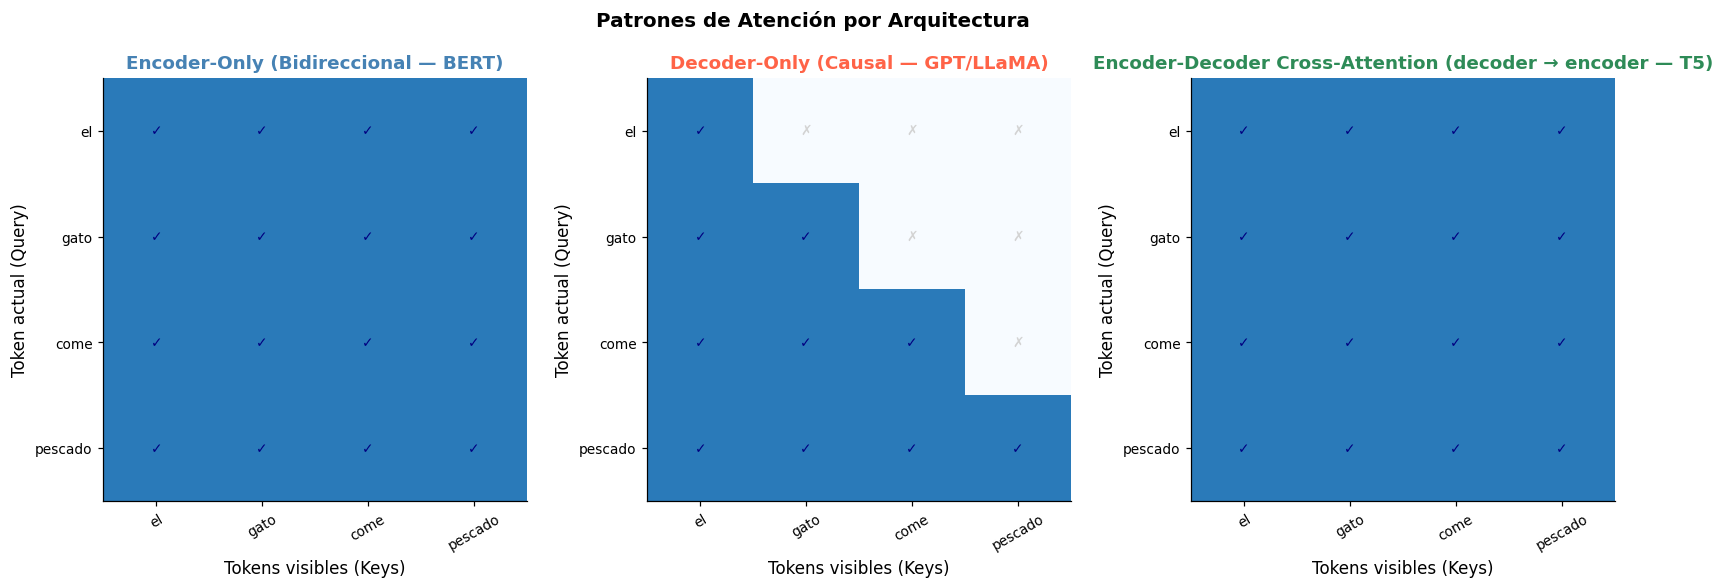

La máscara define si el modelo COMPRENDE (bidirecional) o GENERA (causal)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def draw_arch(ax, title, mask_fn, tokens, color):
    n = len(tokens)
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            mat[i, j] = 1 if mask_fn(i, j, n) else 0
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=1.4)
    ax.set_xticks(range(n)); ax.set_xticklabels(tokens, fontsize=9, rotation=30)
    ax.set_yticks(range(n)); ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel('Tokens visibles (Keys)'); ax.set_ylabel('Token actual (Query)')
    ax.set_title(title, fontweight='bold', color=color)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, '✓' if mat[i,j] else '✗', ha='center', va='center',
                    fontsize=9, color='navy' if mat[i,j] else 'lightgray')

tokens = ['el', 'gato', 'come', 'pescado']

draw_arch(axes[0], 'Encoder-Only (Bidireccional — BERT)',
          lambda i,j,n: True, tokens, 'steelblue')

draw_arch(axes[1], 'Decoder-Only (Causal — GPT/LLaMA)',
          lambda i,j,n: j <= i, tokens, 'tomato')

# Encoder-Decoder: decoder ve todos los del encoder + causales propios
draw_arch(axes[2], 'Encoder-Decoder Cross-Attention (decoder → encoder — T5)',
          lambda i,j,n: True, tokens, 'seagreen')

plt.suptitle('Patrones de Atención por Arquitectura', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print("La máscara define si el modelo COMPRENDE (bidirecional) o GENERA (causal)")


---
## 2. Encoder-Only: BERT y representaciones bidireccionales

### 2.1 ¿Qué es BERT?

**BERT** (*Bidirectional Encoder Representations from Transformers*, Devlin et al. 2018)
utiliza **solo el encoder** del Transformer. Al ser bidireccional, cada token puede atender
a todos los demás → representaciones ricas en contexto.

### 2.2 Pretraining de BERT: dos objetivos

**① Masked Language Modeling (MLM)**  
Se enmascara el 15 % de los tokens y el modelo predice cuáles son:

$$\mathcal{L}_{\text{MLM}} = -\sum_{i \in \mathcal{M}} \log P_\theta(x_i \mid x_{\setminus \mathcal{M}})$$

Estrategia de enmascaramiento:
- 80 % del tiempo → `[MASK]`
- 10 % del tiempo → token aleatorio
- 10 % del tiempo → token original (sin cambio)

**② Next Sentence Prediction (NSP)**  
¿El par de oraciones (A, B) es consecutivo en el texto real?

$$\mathcal{L}_{\text{NSP}} = -[y \log P(\text{IsNext}) + (1-y)\log P(\text{NotNext})]$$

**Objetivo total:**
$$\mathcal{L}_{\text{BERT}} = \mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{NSP}}$$

### 2.3 Tokens especiales de BERT

```
[CLS] el gato        [MASK] pescado [SEP] el perro duerme [SEP]
  ↑                    ↑              ↑                     ↑
clasificación       máscara         separador              fin
```

El embedding de `[CLS]` se usa como representación de la secuencia completa.

### 2.4 Variantes de Encoder-Only

| Modelo | Año | Mejora principal |
|--------|-----|-----------------|
| **BERT** | 2018 | Bidireccionalidad, MLM + NSP |
| **RoBERTa** | 2019 | Sin NSP, más datos, más pasos |
| **DeBERTa** | 2020 | Disentangled attention (contenido ≠ posición) |
| **ALBERT** | 2019 | Factorización de parámetros, SOP en lugar de NSP |


### 2.5 Implementación: BERT-like desde cero

In [ ]:
# ── Tokenizador simple (subword BPE simulado con caracteres) ─────
class SimpleTokenizer:
    def __init__(self, vocab_size=64):
        special = ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
        chars   = list(' abcdefghijklmnopqrstuvwxyzáéíóúñ.,;:?¿!¡')
        all_tokens = special + chars
        self.vocab  = {t: i for i, t in enumerate(all_tokens)} # el gato come
        self.inv    = {i: t for t, i in self.vocab.items()}    # 0123 ...
        self.PAD  = self.vocab['[PAD]']
        self.CLS  = self.vocab['[CLS]']
        self.SEP  = self.vocab['[SEP]']
        self.MASK = self.vocab['[MASK]']

    def encode(self, text, max_len=32):
        tokens = [self.CLS] + [self.vocab.get(c, 1) for c in text.lower()] + [self.SEP]
        tokens = tokens[:max_len]
        pad = [self.PAD] * (max_len - len(tokens))
        return tokens + pad

    def decode(self, ids):
        return ''.join(self.inv.get(i, '?') for i in ids
                       if i not in [self.PAD, self.CLS, self.SEP])

tok = SimpleTokenizer()
sample = "el gato come pescado"
ids    = tok.encode(sample)
print("Texto:   ", sample)
print("Token IDs:", ids[:15], "...")
print("Decode:  ", tok.decode(ids))
print(f"Vocab size: {len(tok.vocab)}")


Texto:    el gato come pescado
Token IDs: [2, 10, 17, 5, 12, 6, 25, 20, 5, 8, 20, 18, 10, 5, 21] ...
Decode:   el gato come pescado
Vocab size: 46


In [ ]:
# ── Modelo BERT-like ─────────────────────────────────────────────
class BERTEmbedding(nn.Module):
    """Token + Segment + Positional embeddings"""
    def __init__(self, vocab_size, d_model, max_len=128, n_segments=2):
        super().__init__()
        self.token   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.segment = nn.Embedding(n_segments, d_model)
        self.pos     = nn.Embedding(max_len, d_model)
        self.norm    = nn.LayerNorm(d_model)
        self.drop    = nn.Dropout(.1) # 10 % FF apagarse durante un step

    def forward(self, x, seg_ids=None):
        B, T = x.shape # Batch, Tokens
        pos  = torch.arange(T, device=x.device).unsqueeze(0)
        if seg_ids is None:
            seg_ids = torch.zeros_like(x)
        emb = self.token(x) + self.pos(pos) + self.segment(seg_ids)
        return self.drop(self.norm(emb))


class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim, dropout=.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d_model, ff_dim), nn.GELU(),
                                   nn.Linear(ff_dim, d_model), nn.Dropout(dropout))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, src_key_padding_mask=None):
        # Self-attention bidireccional (sin máscara causal)
        a, _ = self.attn(x, x, x, key_padding_mask=src_key_padding_mask)
        x = self.norm1(x + a)
        x = self.norm2(x + self.ff(x))
        return x


class TinyBERT(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, n_layers=3,
                 ff_dim=256, max_len=64):
        super().__init__()
        self.emb = BERTEmbedding(vocab_size, d_model, max_len)
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, ff_dim) for _ in range(n_layers)
        ])
        # Cabeza MLM: predice token original enmascarado [MASK]
        self.mlm_head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Linear(d_model, vocab_size)
        )
        # Cabeza NSP: predice si B sigue a A Next setence prediction
        self.nsp_head = nn.Linear(d_model, 2)

    def forward(self, x, seg_ids=None, pad_mask=None):
        h = self.emb(x, seg_ids)
        for layer in self.layers:
            h = layer(h, src_key_padding_mask=pad_mask)
        # [CLS] token → NSP
        cls_repr = h[:, 0, :]
        mlm_logits = self.mlm_head(h)          # (B, T, vocab)
        nsp_logits = self.nsp_head(cls_repr)   # (B, 2)
        return mlm_logits, nsp_logits, h

VOCAB = len(tok.vocab)
D_MODEL = 64
bert = TinyBERT(VOCAB, d_model=D_MODEL, n_heads=4, n_layers=3).to(DEVICE)
n_params = sum(p.numel() for p in bert.parameters())
print(f"TinyBERT · {n_params:,} parámetros · d_model={D_MODEL}")

# Test forward pass
x_test = torch.randint(5, VOCAB, (4, 32)).to(DEVICE)
mlm_out, nsp_out, hidden = bert(x_test)
print(f"Input: {x_test.shape}")
print(f"MLM logits: {mlm_out.shape}  (B, T, vocab)")
print(f"NSP logits: {nsp_out.shape}  (B, 2)")
print(f"Hidden:     {hidden.shape}   (B, T, d_model)")


TinyBERT · 164,656 parámetros · d_model=64
Input: torch.Size([4, 32])
MLM logits: torch.Size([4, 32, 46])  (B, T, vocab)
NSP logits: torch.Size([4, 2])  (B, 2)
Hidden:     torch.Size([4, 32, 64])   (B, T, d_model)


Epoch  20 | MLM Loss: 1.9665
Epoch  40 | MLM Loss: 1.4240
Epoch  60 | MLM Loss: 1.2888


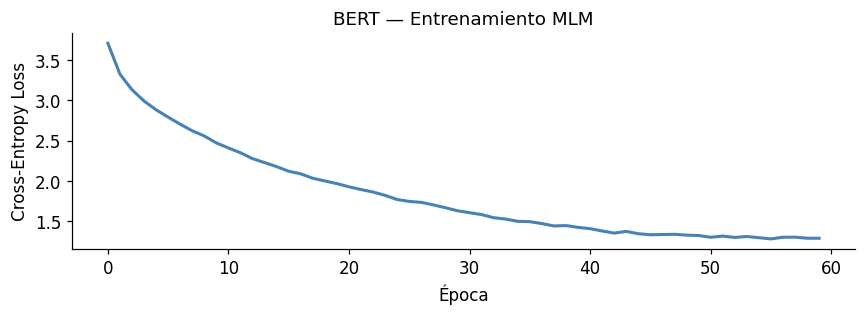

In [ ]:
# ── Entrenamiento MLM ────────────────────────────────────────────
corpus = [
    "el gato come pescado fresco todos los dias",
    "el perro duerme en el sofa por la tarde",
    "la luna brilla en el cielo nocturno oscuro",
    "el estudiante estudia matematicas con esfuerzo",
    "los pajaros cantan en el jardin por la manana",
    "la computadora procesa datos muy rapidamente",
    "el sol calienta la tierra durante el verano",
    "los libros contienen mucho conocimiento valioso",
] * 40

MAX_LEN = 32
MLM_PROB = 0.15

def make_mlm_batch(texts, tokenizer, mlm_prob=0.15):
    """Crea un batch con tokens enmascarados para MLM"""
    all_ids, all_labels = [], []
    for txt in texts:
        ids    = torch.tensor(tokenizer.encode(txt, MAX_LEN), dtype=torch.long)
        labels = ids.clone()
        # Enmascarar tokens especiales nunca
        mask_cand = (ids > 4)  # ignora [PAD],[UNK],[CLS],[SEP],[MASK]
        probs     = torch.rand(ids.shape)
        masked    = mask_cand & (probs < mlm_prob)
        # 80% → [MASK], 10% → aleatorio, 10% → original
        r = torch.rand(ids.shape)
        ids[masked & (r < .8)]              = tokenizer.MASK
        ids[masked & (r >= .8) & (r < .9)] = torch.randint(5, len(tokenizer.vocab), (1,))
        labels[~masked] = -100  # ignorar en loss
        all_ids.append(ids); all_labels.append(labels)
    return torch.stack(all_ids), torch.stack(all_labels)

# Dataset
Xb, Lb = make_mlm_batch(corpus, tok)
mlm_ds  = TensorDataset(Xb, Lb)
mlm_loader = DataLoader(mlm_ds, batch_size=32, shuffle=True)

opt_bert  = torch.optim.AdamW(bert.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt_bert, T_max=60)

mlm_history = []
for epoch in range(60):
    total = 0
    for xb, lb in mlm_loader:
        xb, lb = xb.to(DEVICE), lb.to(DEVICE) # CUDA/CPU
        mlm_logits, _, _ = bert(xb)
        loss = F.cross_entropy(mlm_logits.view(-1, VOCAB), lb.view(-1), ignore_index=-100)
        opt_bert.zero_grad(); loss.backward(); opt_bert.step()
        total += loss.item()
    scheduler.step()
    mlm_history.append(total / len(mlm_loader))
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | MLM Loss: {mlm_history[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(mlm_history, color='steelblue', lw=2)
ax.set_title('BERT — Entrenamiento MLM'); ax.set_xlabel('Época'); ax.set_ylabel('Cross-Entropy Loss')
plt.tight_layout(); plt.show()


In [ ]:
# ── Inferencia: recuperar tokens enmascarados ────────────────────
bert.eval()

def predict_masked(text, mask_positions, topk=3):
    ids  = torch.tensor(tok.encode(text, MAX_LEN)).unsqueeze(0).to(DEVICE)
    orig_tokens = ids.clone()
    for pos in mask_positions:
        ids[0, pos+1] = tok.MASK  # +1 por [CLS]
    with torch.no_grad():
        logits, _, _ = bert(ids)
    print(f"\nTexto: '{text}'")
    for pos in mask_positions:
        top = torch.topk(logits[0, pos+1], topk)
        candidates = [(tok.inv.get(i.item(),'?'), f"{p:.1%}")
                      for i, p in zip(top.indices, F.softmax(top.values, dim=0))]
        real_token = tok.inv.get(orig_tokens[0, pos+1].item(), '?')
        print(f"  Pos {pos} (real='{real_token}'): {candidates}")

predict_masked("el gato come pescado", mask_positions=[2, 3])
predict_masked("el perro duerme en el sofa", mask_positions=[1, 3])
print("\nBERT predice tokens enmascarados usando CONTEXTO BIDIRECCIONAL")



Texto: 'el gato come pescado'
  Pos 2 (real=' '): [(' ', '83.7%'), ('s', '14.3%'), ('t', '1.9%')]
  Pos 3 (real='g'): [(' ', '55.3%'), ('c', '22.5%'), ('g', '22.2%')]

Texto: 'el perro duerme en el sofa'
  Pos 1 (real='l'): [('l', '86.5%'), ('a', '8.6%'), ('o', '4.9%')]
  Pos 3 (real='p'): [('e', '36.0%'), ('p', '32.2%'), ('r', '31.8%')]

BERT predice tokens enmascarados usando CONTEXTO BIDIRECCIONAL


---
## 3. Decoder-Only: GPT y generación autoregresiva

### 3.1 La familia GPT

**GPT** (*Generative Pre-trained Transformer*, Radford et al. 2018) usa solo el **decoder**
con atención causal. A diferencia de BERT, GPT es **generativo**: predice el siguiente token.

| Modelo | Año | Parámetros | Novedad |
|--------|-----|-----------|---------|
| GPT-1 | 2018 | 117M | Pretraining + fine-tuning |
| GPT-2 | 2019 | 1.5B | Zero-shot, generación fluida |
| GPT-3 | 2020 | 175B | Few-shot, in-context learning |
| GPT-4 | 2023 | ~1T (estimado) | Multimodal, RLHF |

### 3.2 Objetivo: Causal Language Modeling (CLM)

$$\mathcal{L}_{\text{CLM}} = -\frac{1}{T} \sum_{t=1}^{T} \log P_\theta(x_t \mid x_1, \ldots, x_{t-1})$$

La máscara causal garantiza que $P(x_t \mid x_{<t})$ no "vea el futuro":

$$M_{ij} = \begin{cases} 0 & \text{si } j \leq i \\ -\infty & \text{si } j > i \end{cases}$$

### 3.3 Escalado y Leyes de Escala (Scaling Laws)

Kaplan et al. (2020) — OpenAI — demostraron que la pérdida sigue una ley de potencia:

$$\mathcal{L} \propto N^{-\alpha_N} \cdot D^{-\alpha_D} \cdot C^{-\alpha_C}$$

donde $N$ = parámetros, $D$ = tokens de entrenamiento, $C$ = cómputo.

**Chinchilla (Hoffmann et al. 2022):** el óptimo es entrenar con $\approx 20 \times N$ tokens.

### 3.4 GPT vs BERT: ¿cuándo usar cada uno?

| Criterio | BERT (Encoder) | GPT (Decoder) |
|----------|---------------|---------------|
| Tarea | Clasificación, NER, QA extractivo | Generación, completado, chat |
| Atención | Bidireccional | Causal (izquierda → derecha) |
| Fine-tuning | Cabeza de clasificación sobre [CLS] | Seguir generando / prompting |
| Velocidad inferencia | Rápido (un solo forward) | Lento (autoregresivo) |


### 3.5 Implementación: GPT-like desde cero

In [ ]:
# ── GPT Decoder-Only ─────────────────────────────────────────────
class CausalSelfAttention(nn.Module):
    """Multi-head attention con máscara causal"""
    def __init__(self, d_model, n_heads, max_len=128, dropout=.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.qkv     = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj    = nn.Linear(d_model, d_model, bias=False)
        self.drop    = nn.Dropout(dropout)
        # Máscara causal (buffer: no es parámetro, pero se mueve con .to(device))
        mask = torch.tril(torch.ones(max_len, max_len)).view(1, 1, max_len, max_len)
        self.register_buffer('mask', mask)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).split(C, dim=-1)   # 3 × (B, T, d_model)
        def reshape(t):
            return t.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        Q, K, V = map(reshape, qkv)           # (B, n_heads, T, d_k)

        scores = Q @ K.transpose(-2,-1) / math.sqrt(self.d_k)
        scores = scores.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
        w = self.drop(F.softmax(scores, dim=-1))
        out = (w @ V).transpose(1,2).contiguous().view(B, T, C)
        return self.proj(out), w


class GPTBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim, max_len=128, dropout=.1):
        super().__init__()
        self.attn = CausalSelfAttention(d_model, n_heads, max_len, dropout)
        self.ff   = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout)
        )
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        a, w = self.attn(self.ln1(x))
        x = x + a
        x = x + self.ff(self.ln2(x))
        return x, w


class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4,
                 ff_dim=512, max_len=64):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop    = nn.Dropout(.1)
        self.blocks  = nn.ModuleList([
            GPTBlock(d_model, n_heads, ff_dim, max_len) for _ in range(n_layers)
        ])
        self.ln_f    = nn.LayerNorm(d_model)
        self.head    = nn.Linear(d_model, vocab_size, bias=False)
        # Weight tying: emb y head comparten pesos
        self.head.weight = self.tok_emb.weight
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def forward(self, x, return_attn=False):
        B, T = x.shape
        pos  = torch.arange(T, device=x.device).unsqueeze(0)
        h    = self.drop(self.tok_emb(x) + self.pos_emb(pos))
        attns = []
        for block in self.blocks:
            h, w = block(h)
            if return_attn: attns.append(w)
        h = self.ln_f(h)
        logits = self.head(h)  # (B, T, vocab)
        return logits, attns

n_params_gpt = sum(p.numel() for p in TinyGPT(VOCAB).parameters())
print(f"TinyGPT · {n_params_gpt:,} parámetros")

gpt = TinyGPT(VOCAB, d_model=128, n_heads=4, n_layers=4, ff_dim=512, max_len=64).to(DEVICE)
x_t = torch.randint(5, VOCAB, (2, 20)).to(DEVICE)
out, _ = gpt(x_t)
print(f"Input: {x_t.shape} → Logits: {out.shape}")


TinyGPT · 805,376 parámetros
Input: torch.Size([2, 20]) → Logits: torch.Size([2, 20, 46])


Epoch  20 | Loss: 0.0907 | Perplexity: 1.09
Epoch  40 | Loss: 0.0770 | Perplexity: 1.08
Epoch  60 | Loss: 0.0725 | Perplexity: 1.08
Epoch  80 | Loss: 0.0720 | Perplexity: 1.07


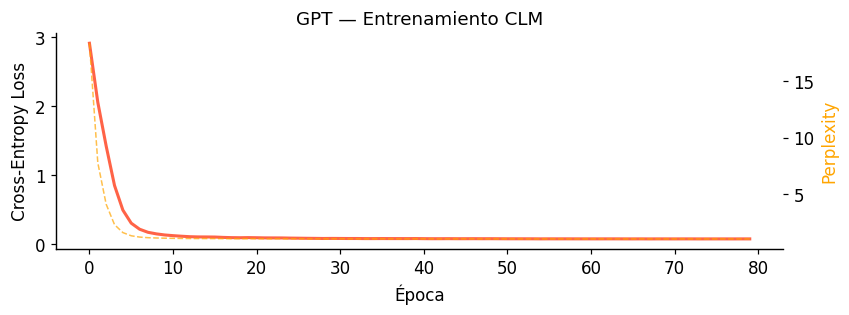

In [ ]:
# ── Entrenamiento GPT (CLM) ──────────────────────────────────────
# Datos: secuencias de texto, predecir el siguiente token
corpus_gpt = corpus * 2  # reusar corpus de antes

def make_clm_batch(texts, tokenizer, max_len=32):
    xs, ys = [], []
    for txt in texts:
        ids = tokenizer.encode(txt, max_len+1)
        xs.append(ids[:-1])   # input: todos menos el último
        ys.append(ids[1:])    # target: todos menos el primero (shifted)
    return torch.tensor(xs, dtype=torch.long), torch.tensor(ys, dtype=torch.long)

Xg, Yg = make_clm_batch(corpus_gpt, tok, max_len=31)
gpt_loader = DataLoader(TensorDataset(Xg, Yg), batch_size=32, shuffle=True)

opt_gpt = torch.optim.AdamW(gpt.parameters(), lr=3e-4, weight_decay=0.1)
sched_g = torch.optim.lr_scheduler.CosineAnnealingLR(opt_gpt, T_max=80)

gpt_history = []
for epoch in range(80):
    total = 0
    for xb, yb in gpt_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)  #CUDA/CPU
        logits, _ = gpt(xb)
        loss = F.cross_entropy(logits.view(-1, VOCAB), yb.view(-1), ignore_index=tok.PAD)
        opt_gpt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(gpt.parameters(), 1.0)  # gradient clipping
        opt_gpt.step()
        total += loss.item()
    sched_g.step()
    gpt_history.append(total / len(gpt_loader))
    if (epoch+1) % 20 == 0:
        perplexity = math.exp(gpt_history[-1])
        print(f"Epoch {epoch+1:3d} | Loss: {gpt_history[-1]:.4f} | Perplexity: {perplexity:.2f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(gpt_history, color='tomato', lw=2)
ax.set_title('GPT — Entrenamiento CLM'); ax.set_xlabel('Época'); ax.set_ylabel('Cross-Entropy Loss')
ax2 = ax.twinx()
ax2.plot([math.exp(l) for l in gpt_history], color='orange', lw=1, ls='--', alpha=.7)
ax2.set_ylabel('Perplexity', color='orange')
plt.tight_layout(); plt.show()


In [ ]:
# ── Generación con GPT (top-k + nucleus sampling) ────────────────
def gpt_generate(model, tokenizer, prompt, max_new=40, temperature=0.8, top_k=10, top_p=0.9):
    model.eval()
    ids = tokenizer.encode(prompt, 64)
    # Quitar padding al final
    while ids and ids[-1] == tokenizer.PAD: ids.pop()
    generated = list(ids)

    with torch.no_grad():
        for _ in range(max_new):
            ctx = torch.tensor([generated[-63:]], dtype=torch.long).to(DEVICE)
            logits, _ = model(ctx)
            next_logits = logits[0, -1] / temperature

            # Top-K
            if top_k > 0:
                topk_val, _ = torch.topk(next_logits, top_k)
                next_logits[next_logits < topk_val[-1]] = float('-inf')

            # Nucleus (top-p)
            probs_sorted, sorted_idx = torch.sort(F.softmax(next_logits, dim=-1), descending=True)
            cum = torch.cumsum(probs_sorted, dim=0)
            mask_nuc = cum - probs_sorted > top_p
            probs_sorted[mask_nuc] = 0
            probs_sorted /= probs_sorted.sum()
            next_tok = sorted_idx[torch.multinomial(probs_sorted, 1)].item()

            if next_tok == tokenizer.SEP: break
            generated.append(next_tok)

    return tokenizer.decode(generated)

print("Generación con TinyGPT:")
for prompt in ["el gato", "el perro duerme", "los libros"]:
    result = gpt_generate(gpt, tok, prompt, max_new=30)
    print(f"  Prompt: '{prompt}'")
    print(f"  Generado: '{result}'\n")

print("💡 Top-K y Nucleus sampling balancean creatividad y coherencia")


Generación con TinyGPT:
  Prompt: 'el gato'
  Generado: 'el gatotome pescado fresco todo fato '

  Prompt: 'el perro duerme'
  Generado: 'el perro duermel el frelo por perormero pues '

  Prompt: 'los libros'
  Generado: 'los librosl ctienen mucho conononononono'

💡 Top-K y Nucleus sampling balancean creatividad y coherencia


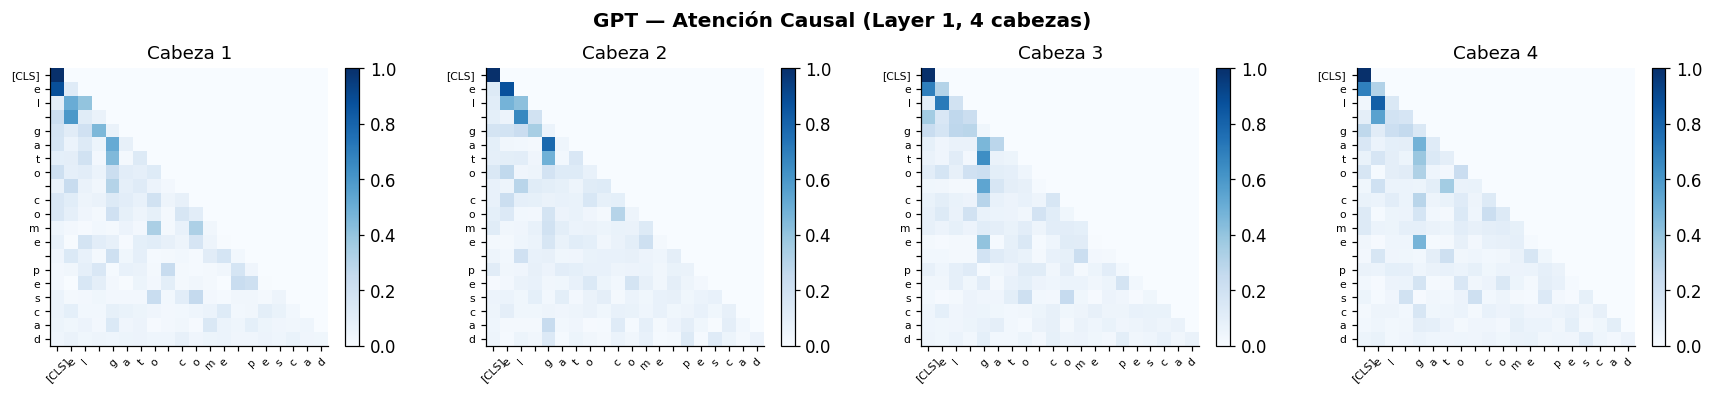

⬛ El triángulo inferior = máscara causal: solo ve el pasado


In [ ]:
# ── Visualizar atención causal ────────────────────────────────────
gpt.eval()
sample_text = "el gato come pescado"
sample_ids  = torch.tensor([tok.encode(sample_text, 20)]).to(DEVICE)
# Quitar padding para visualizar
T_vis = sum(1 for i in tok.encode(sample_text, 20) if i != tok.PAD)

with torch.no_grad():
    _, attns = gpt(sample_ids, return_attn=True)

# Mostrar layer 0, las 4 cabezas
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
tokens_str = ['[CLS]'] + list(sample_text) + ['[SEP]']
tokens_str = tokens_str[:T_vis]

for head in range(4):
    w = attns[0][0, head, :T_vis, :T_vis].cpu().numpy()
    ax = axes[head]
    im = ax.imshow(w, cmap='Blues', vmin=0)
    ax.set_title(f'Cabeza {head+1}')
    ax.set_xticks(range(T_vis)); ax.set_xticklabels(tokens_str, fontsize=7, rotation=45)
    ax.set_yticks(range(T_vis)); ax.set_yticklabels(tokens_str, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('GPT — Atención Causal (Layer 1, 4 cabezas)', fontweight='bold')
plt.tight_layout(); plt.show()
print("⬛ El triángulo inferior = máscara causal: solo ve el pasado")


---
## 4. LLaMA, DeepSeek y Qwen — Eficiencia y Razonamiento

### 4.1 Evolución post-GPT: hacia modelos eficientes y abiertos

La familia de modelos **Decoder-Only** ha evolucionado introduciendo mejoras arquitectónicas
significativas respecto al GPT original.

### 4.2 Innovaciones clave de LLaMA

**LLaMA** (Meta, 2023) — Modelos de código abierto que igualan o superan a GPT-3 con menos parámetros.

**① RMSNorm** (en lugar de LayerNorm):

$$\text{RMSNorm}(x) = \frac{x}{\text{RMS}(x)} \cdot g, \qquad \text{RMS}(x) = \sqrt{\frac{1}{d}\sum_{i=1}^d x_i^2}$$

Más rápido: no necesita calcular media, solo la norma RMS.

**② RoPE — Rotary Position Embedding** (en lugar de PE aditivo):

$$q_m \cdot k_n = \text{Re}[(q_m e^{im\theta})(k_n e^{in\theta})^*] = f(q, m) \cdot f(k, n)$$

Codifica posición **relativa** directamente en el producto Q·K → mejor generalización a secuencias largas.

**③ SwiGLU** (en lugar de GELU en FFN):

$$\text{SwiGLU}(x, W, V) = \text{Swish}(xW) \odot (xV), \qquad \text{Swish}(x) = x \cdot \sigma(x)$$

**④ Grouped Query Attention (GQA)** — LLaMA 2/3:

En lugar de $h$ cabezas Q, K, V → $h$ cabezas Q pero solo $g < h$ cabezas K, V (compartidas):

$$\text{GQA: } \; Q \in \mathbb{R}^{h \times d_k}, \; K, V \in \mathbb{R}^{g \times d_k}, \; g \ll h$$

Reduce el **KV-cache** en inferencia drásticamente.

---

### 4.3 DeepSeek — Arquitecturas de razonamiento

**DeepSeek** (DeepSeek AI, 2024–2025) introduce innovaciones en razonamiento y eficiencia:

**① Mixture of Experts (MoE)**:

$$y = \sum_{i=1}^K G_i(x) \cdot E_i(x), \qquad G(x) = \text{TopK}(\text{softmax}(W_g x))$$

Solo se activan $K$ expertos de $N$ totales → mismo cómputo, más capacidad.

**② Multi-Head Latent Attention (MLA)** — DeepSeek-V2/V3:

Comprime K y V a un espacio latente de baja dimensión antes de almacenar en KV-cache:

$$c_{KV} = W^{DKV} h_t, \qquad K_t = W^{UK} c_{KV}, \quad V_t = W^{UV} c_{KV}$$

Reduce el KV-cache en ~$5\times$ sin pérdida significativa de calidad.

**③ GRPO** — Group Relative Policy Optimization (para razonamiento):  
En lugar de un critic (como PPO), estima la baseline desde el grupo de respuestas:

$$\mathcal{L}_{\text{GRPO}} = -\mathbb{E}\!\left[\frac{\pi_\theta(a|s)}{\pi_{\text{ref}}(a|s)} \cdot \hat{A} - \beta D_{KL}(\pi_\theta \| \pi_{\text{ref}})\right]$$

---

### 4.4 Qwen — Multilingüe y multimodal

**Qwen** (Alibaba, 2023–2025):

- **Tokenizador**: vocabulario ampliado para chino, árabe, código → cobertura multilingüe eficiente  
- **Qwen-VL**: encoder visual conectado al LLM mediante un **Q-Former** (cross-attention)  
- **Qwen2.5-Math / Coder**: fine-tuning especializado con datos de dominio

---

### 4.5 Comparativa arquitectónica resumida

| Componente | GPT-2 | LLaMA 3 | DeepSeek-V3 | Qwen2.5 |
|-----------|-------|---------|-------------|---------|
| Norm | Pre-LN | RMSNorm | RMSNorm | RMSNorm |
| PE | Learned abs. | RoPE | RoPE | RoPE |
| FFN | GELU | SwiGLU | SwiGLU (MoE) | SwiGLU |
| Atención | MHA | GQA | MLA | GQA |
| Parámetros | 1.5B | 405B | 671B (MoE) | 72B |
| Contexto | 1K | 128K | 128K | 128K |


### 4.6 Implementación: RMSNorm, RoPE, SwiGLU y GQA

In [ ]:
# ── ① RMSNorm ────────────────────────────────────────────────────
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.g   = nn.Parameter(torch.ones(d))
        self.eps = eps
    def forward(self, x):
        rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).sqrt()
        return (x / rms) * self.g

# ── ② RoPE ───────────────────────────────────────────────────────
def precompute_rope(d_k, max_len=512, base=10000):
    theta = 1.0 / (base ** (torch.arange(0, d_k, 2).float() / d_k))
    pos   = torch.arange(max_len).float()
    freqs = torch.outer(pos, theta)                        # (max_len, d_k//2)
    return torch.cos(freqs), torch.sin(freqs)              # cos, sin tables

def apply_rope(q, cos, sin):
    """Aplica RoPE a un tensor q de forma (B, n_heads, T, d_k)"""
    d = q.shape[-1]
    q1, q2 = q[..., :d//2], q[..., d//2:]
    cos_t  = cos[:q.shape[2], :d//2].unsqueeze(0).unsqueeze(0)
    sin_t  = sin[:q.shape[2], :d//2].unsqueeze(0).unsqueeze(0)
    return torch.cat([q1*cos_t - q2*sin_t, q1*sin_t + q2*cos_t], dim=-1)

# ── ③ SwiGLU ─────────────────────────────────────────────────────
class SwiGLU(nn.Module):
    def __init__(self, d_model, ff_dim):
        super().__init__()
        self.W  = nn.Linear(d_model, ff_dim, bias=False)
        self.V  = nn.Linear(d_model, ff_dim, bias=False)
        self.W2 = nn.Linear(ff_dim, d_model, bias=False)
    def forward(self, x):
        return self.W2(F.silu(self.W(x)) * self.V(x))   # Swish(xW) ⊙ xV

# ── ④ Grouped Query Attention ─────────────────────────────────────
class GroupedQueryAttention(nn.Module):
    """h cabezas Q, g cabezas K/V (g | h)"""
    def __init__(self, d_model, n_heads, n_kv_heads, max_len=128):
        super().__init__()
        assert n_heads % n_kv_heads == 0
        self.n_heads    = n_heads
        self.n_kv_heads = n_kv_heads
        self.n_rep      = n_heads // n_kv_heads   # cuántas Q por cada K/V
        self.d_k        = d_model // n_heads

        self.Wq = nn.Linear(d_model, n_heads * self.d_k, bias=False)
        self.Wk = nn.Linear(d_model, n_kv_heads * self.d_k, bias=False)
        self.Wv = nn.Linear(d_model, n_kv_heads * self.d_k, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
       # Adiciona RoPE
        cos, sin = precompute_rope(self.d_k, max_len)
        self.register_buffer('cos', cos); self.register_buffer('sin', sin)
        mask = torch.tril(torch.ones(max_len, max_len))
        self.register_buffer('mask', mask)

    def forward(self, x):
        B, T, _ = x.shape
        def split(w, h): return w.view(B, T, h, self.d_k).transpose(1,2)

        Q = split(self.Wq(x), self.n_heads)                # (B, n_heads, T, d_k)
        K = split(self.Wk(x), self.n_kv_heads)             # (B, n_kv, T, d_k)
        V = split(self.Wv(x), self.n_kv_heads)

        # Aplicar RoPE a Q y K
        Q = apply_rope(Q, self.cos, self.sin)
        K = apply_rope(K, self.cos, self.sin)

        # Repetir K y V para igualar n_heads
        K = K.repeat_interleave(self.n_rep, dim=1)         # (B, n_heads, T, d_k)
        V = V.repeat_interleave(self.n_rep, dim=1)

        scores = Q @ K.transpose(-2,-1) / math.sqrt(self.d_k)
        scores = scores.masked_fill(self.mask[:T,:T].unsqueeze(0).unsqueeze(0)==0, float('-inf'))
        w = F.softmax(scores, dim=-1)
        out = (w @ V).transpose(1,2).contiguous().view(B, T, -1)
        return self.Wo(out)

# ── Test integrado ────────────────────────────────────────────────
D, H, KVH = 64, 8, 2   # 8 Q-heads, 2 KV-heads → GQA con ratio 4×
x_demo = torch.randn(2, 16, D)

gqa  = GroupedQueryAttention(D, H, KVH, max_len=64)
norm = RMSNorm(D)
ffn  = SwiGLU(D, D * 4)

out_gqa  = gqa(x_demo)
out_norm = norm(x_demo)
out_ffn  = ffn(x_demo)

print("GQA output:", out_gqa.shape)
print("RMSNorm:   ", out_norm.shape)
print("SwiGLU:    ", out_ffn.shape)
print(f"\nGQA: {H} Q-heads, {KVH} KV-heads → ahorra {(H-KVH)/H:.0%} en KV-cache")


GQA output: torch.Size([2, 16, 64])
RMSNorm:    torch.Size([2, 16, 64])
SwiGLU:     torch.Size([2, 16, 64])

GQA: 8 Q-heads, 2 KV-heads → ahorra 75% en KV-cache


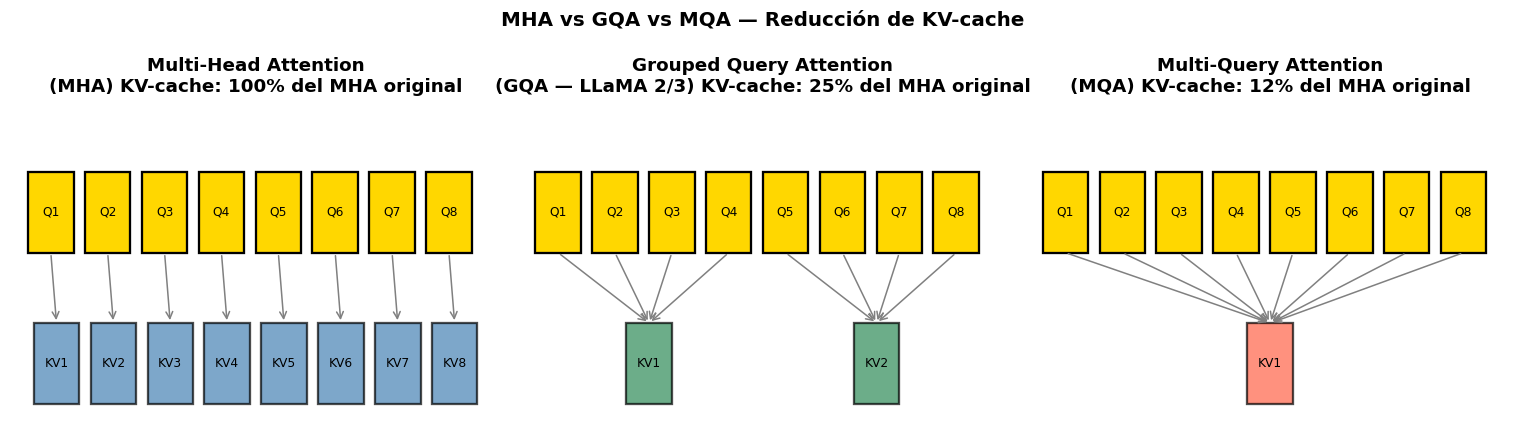

GQA y MQA reducen drásticamente la memoria en inferencia


In [ ]:
# ── Comparación visual: MHA vs GQA vs MQA ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

configs = [
    ('Multi-Head Attention\n(MHA)', 8, 8, 'steelblue'),
    ('Grouped Query Attention\n(GQA — LLaMA 2/3)', 8, 2, 'seagreen'),
    ('Multi-Query Attention\n(MQA)', 8, 1, 'tomato'),
]

for ax, (title, n_q, n_kv, color) in zip(axes, configs):
    # Dibujar cabezas Q
    for i in range(n_q):
        ax.add_patch(plt.Rectangle((i, 1.5), .8, .8, color='gold', ec='k', lw=1.5))
        ax.text(i+.4, 1.9, f'Q{i+1}', ha='center', va='center', fontsize=8)
    # Dibujar cabezas KV
    kv_step = n_q / n_kv
    for j in range(n_kv):
        cx = j * kv_step + (kv_step - .8) / 2
        ax.add_patch(plt.Rectangle((cx, 0), .8, .8, color=color, alpha=.7, ec='k', lw=1.5))
        ax.text(cx+.4, .4, f'KV{j+1}', ha='center', va='center', fontsize=8)
        # Flechas Q→KV
        for i in range(int(j*kv_step), int((j+1)*kv_step)):
            ax.annotate('', xy=(cx+.4, .8), xytext=(i+.4, 1.5),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=1))

    kv_mb = n_kv / 8 * 100
    ax.set_xlim(-.3, n_q+.3); ax.set_ylim(-.2, 3)
    ax.set_title(f'{title} KV-cache: {kv_mb:.0f}% del MHA original', fontweight='bold')
    ax.axis('off')

plt.suptitle('MHA vs GQA vs MQA — Reducción de KV-cache', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print("GQA y MQA reducen drásticamente la memoria en inferencia")


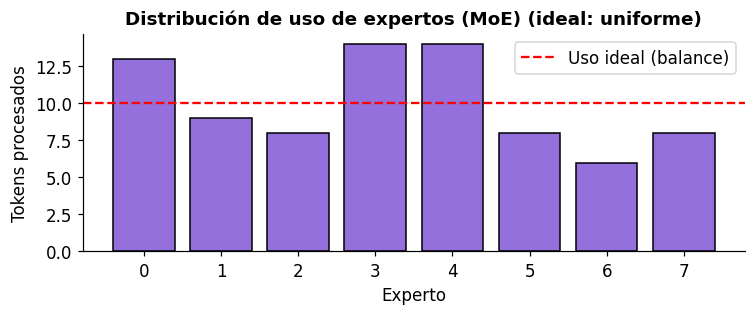

MoE output: torch.Size([4, 10, 64])
Parámetros activos por token: 2/8 expertos = 25% del total


In [ ]:
# ── Mixture of Experts (MoE) — concepto ─────────────────────────
class MoELayer(nn.Module):
    """Capa MoE simple: N expertos, activa top-K"""
    def __init__(self, d_model, n_experts=8, top_k=2, ff_dim=256):
        super().__init__()
        self.n_experts = n_experts
        self.top_k     = top_k
        self.gate      = nn.Linear(d_model, n_experts, bias=False)
        self.experts   = nn.ModuleList([
            nn.Sequential(nn.Linear(d_model, ff_dim), nn.GELU(),
                          nn.Linear(ff_dim, d_model))
            for _ in range(n_experts)
        ])

    def forward(self, x):
        B, T, D = x.shape
        x_flat  = x.view(-1, D)                          # (B*T, D)
        gate    = self.gate(x_flat)                       # (B*T, n_experts)
        # Top-K experts por token
        topk_w, topk_idx = torch.topk(F.softmax(gate, dim=-1), self.top_k, dim=-1)
        topk_w = topk_w / topk_w.sum(dim=-1, keepdim=True)   # renormalizar

        out = torch.zeros_like(x_flat)
        for k in range(self.top_k):
            for e in range(self.n_experts):
                mask = (topk_idx[:, k] == e)
                if mask.any():
                    out[mask] += topk_w[mask, k:k+1] * self.experts[e](x_flat[mask])
        return out.view(B, T, D), topk_idx

# Test y visualización de activación de expertos
moe = MoELayer(d_model=64, n_experts=8, top_k=2)
x_moe = torch.randn(4, 10, 64)
out_moe, expert_ids = moe(x_moe)

# Distribución de uso de expertos
flat_ids = expert_ids.view(-1).numpy()
counts   = Counter(flat_ids.tolist())

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(range(8), [counts.get(i,0) for i in range(8)], color='mediumpurple', ec='k')
ax.set_xlabel('Experto'); ax.set_ylabel('Tokens procesados')
ax.set_title('Distribución de uso de expertos (MoE) (ideal: uniforme)', fontweight='bold')
ax.axhline(len(flat_ids)/8, color='red', ls='--', label='Uso ideal (balance)')
ax.legend()
plt.tight_layout(); plt.show()
print(f"MoE output: {out_moe.shape}")
print(f"Parámetros activos por token: {2}/8 expertos = 25% del total")


---
## 5. Pretraining, Fine-tuning e Instruction Tuning

### 5.1 El pipeline completo de entrenamiento de un LLM

```
  Datos crudos (web, libros, código)
          │
          ▼
  ┌─────────────────────┐
  │   PRETRAINING       │  → Aprende distribución del lenguaje
  │   CLM / MLM         │  → Billones de tokens · semanas/meses
  └─────────────────────┘
          │
          ▼ (modelo base)
  ┌─────────────────────┐
  │   FINE-TUNING       │  → Adapta a tarea/dominio específico
  │   SFT / PEFT / LoRA │  → Miles–millones de ejemplos · horas/días
  └─────────────────────┘
          │
          ▼ (modelo fine-tuned)
  ┌─────────────────────┐
  │  INSTRUCTION TUNING │  → Sigue instrucciones en lenguaje natural
  │  SFT + RLHF / DPO   │  → Pares (instrucción, respuesta buena/mala)
  └─────────────────────┘
          │
          ▼ (modelo de chat / asistente)
```

### 5.2 Pretraining

**Objetivo:** aprender $P_\theta(x)$ sobre un corpus masivo.

- **Datos:** Common Crawl, C4, GitHub, libros, Wikipedia (~1–15T tokens)
- **Compute:** miles de GPUs H100 · semanas
- **Loss:** CLM ($-\log P(x_t|x_{<t})$) o MLM











### RLHF — Reinforcement Learning from Human Feedback

$$\mathcal{L}_{\text{RLHF}} = -\mathbb{E}_{(x,y) \sim \pi_\theta}[r_\phi(x,y)] + \beta D_{KL}(\pi_\theta(\cdot|x) \| \pi_{\text{ref}}(\cdot|x))$$

Donde $r_\phi$ es el **reward model** entrenado con preferencias humanas.

### 5.8 Implementación: SFT, LoRA y DPO desde cero

### Instruction Tuning

Transforma el modelo base en un **asistente** mediante pares:

```
SISTEMA: Eres un asistente útil.
USUARIO: ¿Cuál es la capital de Francia?
ASISTENTE: La capital de Francia es París.
```

Formato estándar moderno — **ChatML**:
```
<|im_start|>system\nSistema prompt<|im_end|>
<|im_start|>user\nPregunta del usuario<|im_end|>
<|im_start|>assistant\nRespuesta<|im_end|>
```

In [ ]:
# ══════════════════════════════════════════════════════════════
# 5.8.1  Dataset de Instruction Tuning (simulado)
# ══════════════════════════════════════════════════════════════
INSTRUCTION_DATA = [
    {"instruction": "¿cuál es la capital de francia?",
     "response": "la capital de francia es paris"},
    {"instruction": "resume en una palabra: el perro corre",
     "response": "movimiento"},
    {"instruction": "¿cuántos días tiene una semana?",
     "response": "siete dias"},
    {"instruction": "traduce al ingles: el gato come",
     "response": "the cat eats"},
    {"instruction": "¿qué animal hace miau?",
     "response": "el gato hace miau"},
    {"instruction": "suma tres mas cuatro",
     "response": "tres mas cuatro es siete"},
    {"instruction": "¿qué planeta es el tercero del sistema solar?",
     "response": "la tierra es el tercer planeta"},
    {"instruction": "¿cuántos lados tiene un triángulo?",
     "response": "un triangulo tiene tres lados"},
] * 20

# Formato ChatML simplificado
PROMPT_TEMPLATE = "[inst] {instruction} [/inst] [resp] {response} [/resp]"

def tokenize_sft(examples, tokenizer, max_len=48):
    """Tokeniza y marca qué parte es prompt vs respuesta"""
    xs, ys_masked = [], []
    for ex in examples:
        full    = PROMPT_TEMPLATE.format(**ex)
        prompt  = f"[inst] {ex['instruction']} [/inst] [resp] "
        full_ids   = tokenizer.encode(full, max_len)
        prompt_ids = tokenizer.encode(prompt, max_len)
        prompt_len = sum(1 for i in prompt_ids if i != tokenizer.PAD)

        labels = full_ids.copy()
        # Ignorar loss en el prompt (solo aprender en la respuesta)
        for i in range(min(prompt_len, max_len)):
            labels[i] = -100
        xs.append(full_ids)
        ys_masked.append(labels)
    return (torch.tensor(xs, dtype=torch.long),
            torch.tensor(ys_masked, dtype=torch.long))

X_sft, Y_sft = tokenize_sft(INSTRUCTION_DATA, tok)
sft_loader   = DataLoader(TensorDataset(X_sft, Y_sft), batch_size=16, shuffle=True)

print(f"SFT dataset: {len(INSTRUCTION_DATA)} ejemplos")
print("Ejemplo tokenizado (primeros 20 tokens):")
print("  X:", X_sft[0,:20].tolist())
print("  Y:", Y_sft[0,:20].tolist(), "  (-100 = ignorar en loss)")


SFT dataset: 160 ejemplos
Ejemplo tokenizado (primeros 20 tokens):
  X: [2, 1, 14, 19, 24, 25, 1, 5, 43, 8, 26, 32, 17, 5, 10, 24, 5, 17, 6, 5]
  Y: [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]   (-100 = ignorar en loss)


### LoRA — Low-Rank Adaptation (fine-tuning eficiente)

En lugar de actualizar $W \in \mathbb{R}^{d \times k}$ completo:

$$W' = W + \Delta W = W + BA, \quad B \in \mathbb{R}^{d \times r},\; A \in \mathbb{R}^{r \times k},\; r \ll \min(d,k)$$

Solo se entrenan $A$ y $B$ → **reducción de parámetros entrenables de 10.000x**.

In [ ]:
gpt_lora

TinyGPT(
  (tok_emb): Embedding(46, 128)
  (pos_emb): Embedding(64, 128)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x GPTBlock(
      (attn): CausalSelfAttention(
        (qkv): LoRALinear(
          (linear): Linear(in_features=128, out_features=384, bias=False)
        )
        (proj): LoRALinear(
          (linear): Linear(in_features=128, out_features=128, bias=False)
        )
        (drop): Dropout(p=0.1, inplace=False)
      )
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
        (3): Dropout(p=0.1, inplace=False)
      )
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=128, out_features=46, bias=False)
)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 5.8.2  LoRA — Low-Rank Adaptation
# ══════════════════════════════════════════════════════════════
class LoRALinear(nn.Module):
    """Reemplaza nn.Linear con versión LoRA"""
    def __init__(self, linear: nn.Linear, rank: int = 4, alpha: float = 16.0):
        super().__init__()
        d, k = linear.out_features, linear.in_features
        self.linear = linear          # pesos originales CONGELADOS
        self.rank   = rank
        self.scale  = alpha / rank    # factor de escalado

        # Matrices de bajo rango (los únicos parámetros entrenables)
        self.A = nn.Parameter(torch.randn(rank, k, device=DEVICE) * 0.01)   # inicializar A
        self.B = nn.Parameter(torch.zeros(d, rank, device=DEVICE))           # B = 0 → ΔW=0 al inicio

        # Congelar pesos originales
        for p in self.linear.parameters():
            p.requires_grad_(False)

    def forward(self, x):
        return self.linear(x) + (x @ self.A.T @ self.B.T) * self.scale


def apply_lora(model, rank=4, alpha=16.0, target_modules=('qkv', 'proj')):
    """Aplica LoRA a los módulos objetivo del modelo"""
    for name, module in model.named_modules():
        for attr_name in target_modules:
            if hasattr(module, attr_name):
                orig = getattr(module, attr_name)
                if isinstance(orig, nn.Linear):
                    setattr(module, attr_name, LoRALinear(orig, rank, alpha))
    return model

# Crear modelo GPT y aplicar LoRA
gpt_lora = TinyGPT(VOCAB, d_model=128, n_heads=4, n_layers=4, ff_dim=512, max_len=64).to(DEVICE)
# Copiar pesos entrenados del GPT anterior (simula "modelo base")
gpt_lora.load_state_dict(gpt.state_dict())

# Congelar todo primero
for p in gpt_lora.parameters():
    p.requires_grad_(False)

# Aplicar LoRA solo a proyecciones Q y V
gpt_lora = apply_lora(gpt_lora, rank=4, alpha=16.0)

# Contar parámetros
total   = sum(p.numel() for p in gpt_lora.parameters())
train   = sum(p.numel() for p in gpt_lora.parameters() if p.requires_grad)
print(f"Parámetros totales:      {total:>10,}")
print(f"Parámetros entrenables:  {train:>10,}  (solo LoRA)")
if train > 0:
    print(f"Reducción:               {train/total:.2%} del total → {total/train:.0f}x menos")
else:
    print("Sin parámetros entrenables — revisa target_modules")


Parámetros totales:         817,664
Parámetros entrenables:      12,288  (solo LoRA)
Reducción:               1.50% del total → 67x menos


### Supervised Fine-Tuning (SFT)

Dado un dataset supervisado $\{(x_i, y_i)\}$, minimizamos:

$$\mathcal{L}_{\text{SFT}} = -\frac{1}{|y|} \sum_{t=1}^{|y|} \log P_\theta(y_t \mid x, y_{<t})$$

Solo se calcula loss sobre los tokens de **respuesta** $y$, no sobre el prompt $x$.

  NaN en epoch 2, batch saltado
Epoch  20 | SFT Loss: 1.3195 | LR: 7.52e-05
  NaN en epoch 26, batch saltado
  NaN en epoch 34, batch saltado
Epoch  40 | SFT Loss: 0.8233 | LR: 2.58e-05
  NaN en epoch 47, batch saltado
  NaN en epoch 58, batch saltado
Epoch  60 | SFT Loss: 0.8138 | LR: 1.00e-06
  NaN en epoch 65, batch saltado
  NaN en epoch 67, batch saltado
  NaN en epoch 72, batch saltado
Epoch  80 | SFT Loss: 0.7760 | LR: 2.57e-05
Epoch 100 | SFT Loss: 0.7294 | LR: 7.52e-05


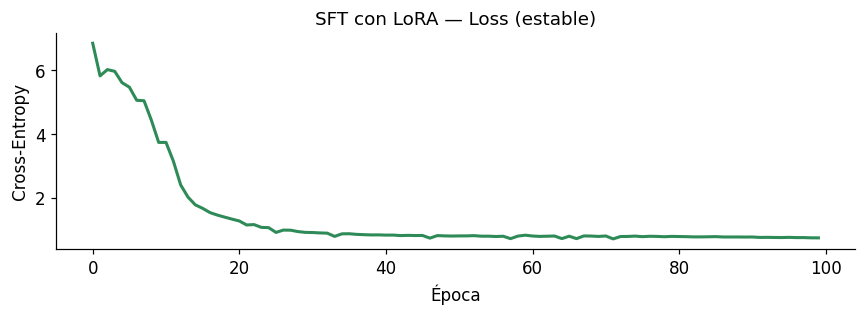

In [ ]:
# ── SFT con LoRA (corregido) ──────────────────────────────────────
opt_sft = torch.optim.AdamW(
    [p for p in gpt_lora.parameters() if p.requires_grad],
    lr=1e-4,           # ← bajamos de 5e-4 a 1e-4
    weight_decay=0.01
)

# Cosine annealing evita que el LR sea demasiado alto al final
sched_sft = torch.optim.lr_scheduler.CosineAnnealingLR(opt_sft, T_max=60, eta_min=1e-6)

sft_history = []
for epoch in range(100):
    total_loss = 0
    gpt_lora.train()
    for xb, yb in sft_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE) # CUDA CPU
        logits, _ = gpt_lora(xb)

        # Label smoothing (0.1) evita que el modelo se vuelva infinitamente
        # confiado → logits se mantienen acotados → sin NaN
        loss = F.cross_entropy(
            logits.view(-1, VOCAB),
            yb.view(-1),
            ignore_index=-100,
            label_smoothing=0.1      # ← clave para estabilidad
        )

        # Guard: si la loss ya es NaN saltamos el batch
        if torch.isnan(loss):
            print(f"  NaN en epoch {epoch+1}, batch saltado")
            continue

        opt_sft.zero_grad()
        loss.backward()

        # Clip más agresivo (0.5 en vez de 1.0)
        torch.nn.utils.clip_grad_norm_(
            [p for p in gpt_lora.parameters() if p.requires_grad], 0.5
        )
        opt_sft.step()
        total_loss += loss.item()

    sched_sft.step()
    epoch_loss = total_loss / len(sft_loader)
    sft_history.append(epoch_loss)

    if (epoch + 1) % 20 == 0:
        lr_now = opt_sft.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d} | SFT Loss: {epoch_loss:.4f} | LR: {lr_now:.2e}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(sft_history, color='seagreen', lw=2)
ax.set_title('SFT con LoRA — Loss (estable)'); ax.set_xlabel('Época'); ax.set_ylabel('Cross-Entropy')
plt.tight_layout(); plt.show()

In [ ]:
# ── Comparación: modelo base vs. modelo SFT ──────────────────────
def instruct_generate(model, tokenizer, instruction, max_new=30, temperature=0.3):
    prompt = f"[inst] {instruction} [/inst] [resp] "
    return gpt_generate(model, tokenizer, prompt, max_new=max_new, temperature=temperature)

print("=" * 55)
print("COMPARACIÓN: Base GPT vs. GPT + SFT (LoRA)")
print("=" * 55)

tests = [
    "¿cuántos días tiene una semana?",
    "¿qué animal hace miau?",
    "suma tres mas cuatro",
]
for inst in tests:
    base_out = gpt_generate(gpt, tok, f"[inst] {inst} [/inst] [resp] ", max_new=20, temperature=0.3)
    sft_out  = instruct_generate(gpt_lora, tok, inst, max_new=20, temperature=0.3)
    print(f"\n📝 Instrucción: '{inst}'")
    print(f"  🔵 Base GPT:  '{base_out[-50:]}'")
    print(f"  🟢 SFT+LoRA:  '{sft_out[-50:]}'")

print("\nSFT enseña al modelo a seguir instrucciones con pocos parámetros")


COMPARACIÓN: Base GPT vs. GPT + SFT (LoRA)

📝 Instrucción: '¿cuántos días tiene una semana?'
  🔵 Base GPT:  '[UNK]inst[UNK] [UNK]resp[UNK] atiento cientientien'
  🟢 SFT+LoRA:  '[UNK]inst[UNK] [UNK]resp[UNK] llllllllllssssssssss'

📝 Instrucción: '¿qué animal hace miau?'
  🔵 Base GPT:  '[UNK]inst[UNK] [UNK]resp[UNK] liento co diento co '
  🟢 SFT+LoRA:  '[UNK]inst[UNK] [UNK]resp[UNK] lllllllllllllllllsss'

📝 Instrucción: 'suma tres mas cuatro'
  🔵 Base GPT:  '[UNK]inst[UNK] [UNK]resp[UNK] anto centientientien'
  🟢 SFT+LoRA:  '[UNK]inst[UNK] [UNK]resp[UNK] lllllllllsssssssssss'

SFT enseña al modelo a seguir instrucciones con pocos parámetros



### 5.6 DPO — Direct Preference Optimization (alternativa a RLHF)

DPO evita el reward model explícito, optimizando directamente con pares (ganador $y_w$, perdedor $y_l$):

$$\mathcal{L}_{\text{DPO}} = -\log \sigma\!\left(\beta \log \frac{\pi_\theta(y_w|x)}{\pi_{\text{ref}}(y_w|x)} - \beta \log \frac{\pi_\theta(y_l|x)}{\pi_{\text{ref}}(y_l|x)}\right)$$

Más simple, estable y sin el bucle PPO.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 5.8.3  DPO — Direct Preference Optimization
# ══════════════════════════════════════════════════════════════
# Dataset de preferencias: (prompt, respuesta buena, respuesta mala)
PREF_DATA = [
    {"prompt":    "¿cuál es la capital de francia?",
     "chosen":    "la capital de francia es paris",
     "rejected":  "no lo se quizas roma o berlin"},
    {"prompt":    "¿cuántos días tiene una semana?",
     "chosen":    "una semana tiene siete dias",
     "rejected":  "depende del calendario puede variar"},
    {"prompt":    "¿qué animal hace miau?",
     "chosen":    "el gato hace miau",
     "rejected":  "muchos animales hacen ese sonido"},
    {"prompt":    "suma tres mas cuatro",
     "chosen":    "tres mas cuatro es igual a siete",
     "rejected":  "no soy bueno en matematicas"},
] * 15

def dpo_loss(policy_log_chosen, policy_log_rejected,
             ref_log_chosen,    ref_log_rejected, beta=0.1):
    """
    DPO loss: -log σ(β * (log π/π_ref para chosen - log π/π_ref para rejected))
    """
    log_ratio_chosen   = policy_log_chosen  - ref_log_chosen
    log_ratio_rejected = policy_log_rejected - ref_log_rejected
    loss = -F.logsigmoid(beta * (log_ratio_chosen - log_ratio_rejected))
    return loss.mean()

def get_log_prob(model, tokenizer, prompt, response, max_len=48):
    """Log-probabilidad de response dado prompt"""
    full   = f"{prompt} {response}"
    prompt_ids  = tokenizer.encode(prompt, max_len)
    full_ids    = torch.tensor(tokenizer.encode(full, max_len), dtype=torch.long).unsqueeze(0).to(DEVICE)
    prompt_len  = sum(1 for i in prompt_ids if i != tokenizer.PAD)

    with torch.no_grad() if model is gpt_lora else torch.enable_grad():
        logits, _ = model(full_ids)
    # Sumar log-probs solo en tokens de respuesta
    log_probs = F.log_softmax(logits[0], dim=-1)
    total = 0
    count = 0
    for t in range(prompt_len, full_ids.shape[1]-1):
        total += log_probs[t, full_ids[0, t+1]].item()
        count += 1
    return total / max(count, 1)

# Calcular DPO loss en el dataset de preferencias
print("Calculando DPO loss de demostración...")
dpo_losses = []
for ex in PREF_DATA[:8]:
    p_c  = get_log_prob(gpt_lora, tok, ex['prompt'], ex['chosen'])
    p_r  = get_log_prob(gpt_lora, tok, ex['prompt'], ex['rejected'])
    r_c  = get_log_prob(gpt,      tok, ex['prompt'], ex['chosen'])
    r_r  = get_log_prob(gpt,      tok, ex['prompt'], ex['rejected'])
    lc   = torch.tensor([p_c]); lr_ = torch.tensor([p_r])
    rc   = torch.tensor([r_c]); rr  = torch.tensor([r_r])
    loss = dpo_loss(lc, lr_, rc, rr, beta=0.1)
    dpo_losses.append(loss.item())
    print(f"  '{ex['prompt'][:35]}...' | chosen logp={p_c:.2f} | rejected logp={p_r:.2f} | loss={loss.item():.3f}")

print(f"\nDPO loss promedio: {np.mean(dpo_losses):.4f}")
print("DPO ajusta el modelo para preferir respuestas buenas sin reward model")


Calculando DPO loss de demostración...
  '¿cuál es la capital de francia?...' | chosen logp=-6.15 | rejected logp=-5.30 | loss=0.748
  '¿cuántos días tiene una semana?...' | chosen logp=-4.81 | rejected logp=-5.97 | loss=0.713
  '¿qué animal hace miau?...' | chosen logp=-4.85 | rejected logp=-5.04 | loss=0.667
  'suma tres mas cuatro...' | chosen logp=-5.35 | rejected logp=-5.32 | loss=0.678
  '¿cuál es la capital de francia?...' | chosen logp=-6.15 | rejected logp=-5.30 | loss=0.748
  '¿cuántos días tiene una semana?...' | chosen logp=-4.81 | rejected logp=-5.97 | loss=0.713
  '¿qué animal hace miau?...' | chosen logp=-4.85 | rejected logp=-5.04 | loss=0.667
  'suma tres mas cuatro...' | chosen logp=-5.35 | rejected logp=-5.32 | loss=0.678

DPO loss promedio: 0.7013
DPO ajusta el modelo para preferir respuestas buenas sin reward model


---
## 6. Evaluación de LLMs

### 6.1 Métricas automáticas

| Métrica | Fórmula | Mide | Limitación |
|---------|---------|------|-----------|
| **Perplexity** | $e^{\mathcal{L}_{\text{CLM}}}$ | Calidad de modelado del lenguaje | No mide calidad de respuesta |
| **BLEU** | Precisión de n-gramas | Similitud léxica (traducción) | No semántico |
| **ROUGE-L** | LCS sobre referencias | Recuerdo de contenido (resumen) | Solo léxico |
| **BERTScore** | Similitud coseno embeddings | Semántica | Costoso |

### 6.2 Perplexity

$$\text{PPL} = e^{-\frac{1}{T}\sum_{t=1}^T \log P(x_t \mid x_{<t})} = e^{\mathcal{L}_{\text{CLM}}}$$

Intuición: cuántas palabras "considera" el modelo en media en cada paso.  
**Perplexity menor = modelo mejor** (más confiado en el texto real).

### 6.3 Benchmarks estándar

| Benchmark | Qué mide |
|-----------|---------|
| **MMLU** | Conocimiento general (57 materias) |
| **HumanEval** | Generación de código Python |
| **GSM8K** | Razonamiento matemático (matemáticas de escuela) |
| **HellaSwag** | Comprensión de lenguaje natural / sentido común |
| **ARC** | Razonamiento de ciencias |
| **MT-Bench** | Instrucción following multi-turno |


### 6.4 Implementación: métricas de evaluación

In [ ]:
# ── Perplexity ───────────────────────────────────────────────────
def compute_perplexity(model, tokenizer, texts, max_len=32):
    model.eval()
    total_nll = 0
    total_tok = 0
    with torch.no_grad():
        for txt in texts:
            ids = tokenizer.encode(txt, max_len)
            x   = torch.tensor([ids[:-1]], dtype=torch.long).to(DEVICE)
            y   = torch.tensor([ids[1:]],  dtype=torch.long).to(DEVICE)
            logits, _ = model(x)
            mask = (y != tokenizer.PAD)
            nll  = F.cross_entropy(logits.view(-1, VOCAB), y.view(-1), ignore_index=tokenizer.PAD,
                                   reduction='sum')
            total_nll += nll.item()
            total_tok += mask.sum().item()
    return math.exp(total_nll / total_tok)

test_texts = [
    "el gato come pescado fresco",
    "el perro duerme en el sofa",
    "la luna brilla en el cielo",
    "el estudiante estudia con esfuerzo",
]

ppl_base = compute_perplexity(gpt,      tok, test_texts)
ppl_sft  = compute_perplexity(gpt_lora, tok, test_texts)

print(f"Perplexity — GPT base:    {ppl_base:.2f}")
print(f"Perplexity — GPT + SFT:  {ppl_sft:.2f}")


Perplexity — GPT base:    2.58
Perplexity — GPT + SFT:  3.49


In [ ]:
# ── BLEU simplificado (unigrama + bigrama) ───────────────────────
from collections import Counter

def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def simple_bleu(hypothesis, reference, max_n=2):
    hyp  = hypothesis.lower().split()
    ref  = reference.lower().split()
    scores = []
    for n in range(1, max_n+1):
        hyp_ng  = Counter(ngrams(hyp, n))
        ref_ng  = Counter(ngrams(ref, n))
        clipped = sum(min(c, ref_ng[g]) for g, c in hyp_ng.items())
        total   = max(sum(hyp_ng.values()), 1)
        scores.append(clipped / total)
    bp = min(1, math.exp(1 - len(ref)/max(len(hyp),1)))  # brevity penalty
    bleu = bp * math.exp(sum(math.log(s+1e-9) for s in scores) / max_n)
    return bleu

# Evaluar respuestas del modelo SFT
eval_cases = [
    ("¿cuántos días tiene una semana?",  "una semana tiene siete dias"),
    ("¿qué animal hace miau?",           "el gato hace miau"),
    ("suma tres mas cuatro",             "tres mas cuatro es siete"),
]

print("Evaluación BLEU — GPT base vs. GPT + SFT (LoRA)")
print("-" * 60)
bleus_base, bleus_sft = [], []

for inst, ref in eval_cases:
    base_resp = gpt_generate(gpt,      tok, f"[inst] {inst} [/inst] [resp] ", max_new=20, temperature=0.2)
    sft_resp  = instruct_generate(gpt_lora, tok, inst, max_new=20, temperature=0.2)

    # Extraer solo la parte de respuesta (después de [resp])
    base_clean = base_resp.split('[resp]')[-1].strip() if '[resp]' in base_resp else base_resp[-30:]
    sft_clean  = sft_resp.split('[resp]')[-1].strip() if '[resp]' in sft_resp  else sft_resp[-30:]

    b_base = simple_bleu(base_clean, ref)
    b_sft  = simple_bleu(sft_clean,  ref)
    bleus_base.append(b_base); bleus_sft.append(b_sft)
    print(f"\n  Instrucción: '{inst}'")
    print(f"  Referencia:  '{ref}'")
    print(f"  Base BLEU={b_base:.3f}: '{base_clean[:50]}'")
    print(f"  SFT  BLEU={b_sft:.3f}: '{sft_clean[:50]}'")

print(f"\n{'─'*40}")
print(f"BLEU promedio — Base: {np.mean(bleus_base):.3f}")
print(f"BLEU promedio — SFT:  {np.mean(bleus_sft):.3f}")


Evaluación BLEU — GPT base vs. GPT + SFT (LoRA)
------------------------------------------------------------

  Instrucción: '¿cuántos días tiene una semana?'
  Referencia:  'una semana tiene siete dias'
  Base BLEU=0.000: 'resp[UNK] atientientientiel di'
  SFT  BLEU=0.000: 'resp[UNK] llllllllllssssssssss'

  Instrucción: '¿qué animal hace miau?'
  Referencia:  'el gato hace miau'
  Base BLEU=0.000: 'resp[UNK] liento co diento co '
  SFT  BLEU=0.000: 'resp[UNK] lllllllllllllllllsss'

  Instrucción: 'suma tres mas cuatro'
  Referencia:  'tres mas cuatro es siete'
  Base BLEU=0.000: 'resp[UNK] anto centientientien'
  SFT  BLEU=0.000: 'resp[UNK] lllllllllsssssssssss'

────────────────────────────────────────
BLEU promedio — Base: 0.000
BLEU promedio — SFT:  0.000


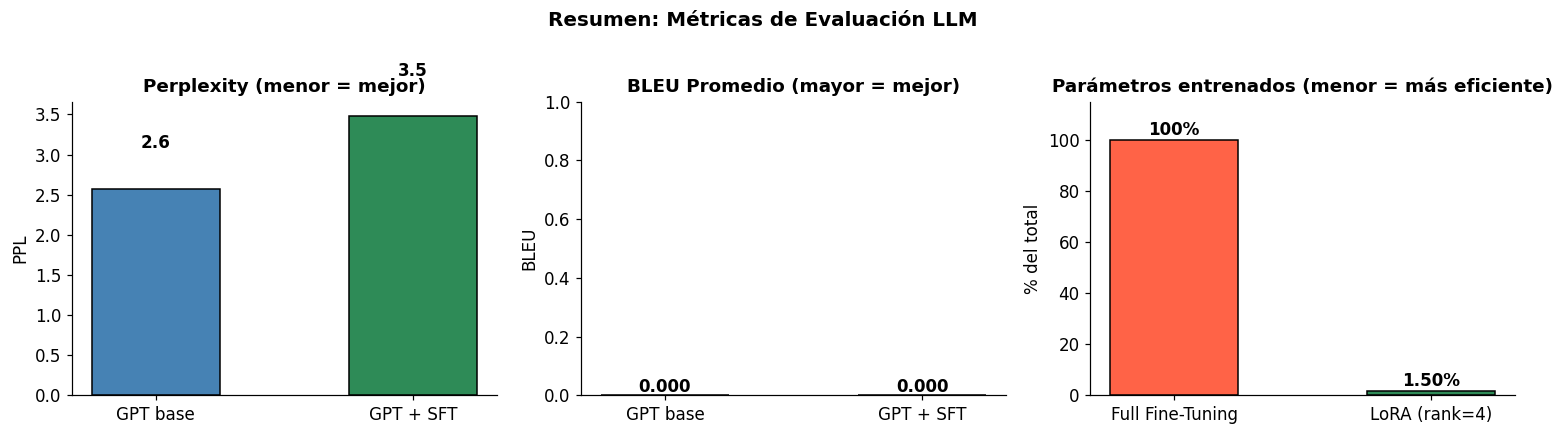

In [ ]:
# ── Dashboard final de comparación ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Perplexity
ax = axes[0]
bars = ax.bar(['GPT base', 'GPT + SFT'], [ppl_base, ppl_sft],
              color=['steelblue', 'seagreen'], ec='k', width=.5)
ax.set_title('Perplexity (menor = mejor)', fontweight='bold')
ax.set_ylabel('PPL')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height()+0.5,
            f'{b.get_height():.1f}', ha='center', fontweight='bold')

# 2. BLEU promedio
ax = axes[1]
bars2 = ax.bar(['GPT base', 'GPT + SFT'], [np.mean(bleus_base), np.mean(bleus_sft)],
               color=['steelblue', 'seagreen'], ec='k', width=.5)
ax.set_title('BLEU Promedio (mayor = mejor)', fontweight='bold')
ax.set_ylabel('BLEU'); ax.set_ylim(0, 1)
for b in bars2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height()+0.01,
            f'{b.get_height():.3f}', ha='center', fontweight='bold')

# 3. % parámetros entrenados (LoRA vs full FT)
ax = axes[2]
ax.bar(['Full Fine-Tuning', 'LoRA (rank=4)'],
       [100, train/total*100], color=['tomato','seagreen'], ec='k', width=.5)
ax.set_title('Parámetros entrenados (menor = más eficiente)', fontweight='bold')
ax.set_ylabel('% del total'); ax.set_ylim(0, 115)
ax.text(1, train/total*100+2, f'{train/total:.2%}', ha='center', fontweight='bold')
ax.text(0, 102, '100%', ha='center', fontweight='bold')

plt.suptitle('Resumen: Métricas de Evaluación LLM', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Resumen Final

### Árbol de decisión: ¿qué arquitectura usar?

```
¿Necesitas GENERAR texto?
├── Sí → Decoder-Only (GPT, LLaMA, DeepSeek, Qwen)
│         └── ¿Necesitas razonamiento complejo?
│              └── Sí → DeepSeek-R1, Qwen-QwQ (chain-of-thought + GRPO)
└── No → ¿Input y Output son secuencias distintas?
         ├── Sí → Encoder-Decoder (T5, BART) — traducción, resumen
         └── No → Encoder-Only (BERT, RoBERTa) — clasificación, NER, QA
```

### Pipeline de entrenamiento moderno

| Fase | Datos | Loss | Resultado |
|------|-------|------|-----------|
| **Pretraining** | Trillones de tokens web | CLM / MLM | Modelo base |
| **SFT** | Miles de pares instrucción-respuesta | CLM sobre respuesta | Modelo que sigue instrucciones |
| **RLHF / DPO** | Pares (buena, mala) con preferencias | DPO / PPO | Modelo alineado |

### Innovaciones clave en LLMs modernos

| Técnica | Beneficio | Dónde |
|---------|-----------|-------|
| **RMSNorm** | Más rápido que LayerNorm | LLaMA, Qwen, DeepSeek |
| **RoPE** | Mejor extrapolación a contextos largos | LLaMA 2+, Qwen |
| **SwiGLU** | Mejor rendimiento que GELU | LLaMA, Qwen, DeepSeek |
| **GQA** | KV-cache 4–8× menor | LLaMA 2+, Qwen 2+ |
| **MoE** | Más capacidad, mismo cómputo | DeepSeek, Mixtral |
| **LoRA** | Fine-tuning 1000× más barato | Cualquier LLM |
| **DPO** | Alineación sin reward model | GPT-4, LLaMA 3 |


In [ ]:
print("=" * 60)
print("  Clase completada: LLMs y Arquitecturas Transformer")
print("=" * 60)
print()
print("Componentes implementados desde cero:")
print("  🔵 BERT  — BERTEmbedding, MLM, NSP, bidireccional")
print("  🔴 GPT   — CausalSelfAttention, CLM, top-K/nucleus sampling")
print("  🟡 LLaMA — RMSNorm, RoPE, SwiGLU, GQA")
print("  🟣 MoE   — Top-K expert routing (DeepSeek style)")
print("  🟢 SFT   — Instruction tuning con ChatML format")
print("  🟢 LoRA  — Adaptación de bajo rango (rank=4, ~0.3% params)")
print("  🟤 DPO   — Direct Preference Optimization")
print("  📊 Eval  — Perplexity + BLEU + dashboard comparativo")


  Clase completada: LLMs y Arquitecturas Transformer

Componentes implementados desde cero:
  🔵 BERT  — BERTEmbedding, MLM, NSP, bidireccional
  🔴 GPT   — CausalSelfAttention, CLM, top-K/nucleus sampling
  🟡 LLaMA — RMSNorm, RoPE, SwiGLU, GQA
  🟣 MoE   — Top-K expert routing (DeepSeek style)
  🟢 SFT   — Instruction tuning con ChatML format
  🟢 LoRA  — Adaptación de bajo rango (rank=4, ~0.3% params)
  🟤 DPO   — Direct Preference Optimization
  📊 Eval  — Perplexity + BLEU + dashboard comparativo
